Loading data and adding some basic information

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load main dataset
df = pd.read_csv("diabetic_data.csv")

# Replace '?' with NaN to properly handle missing values
df = df.replace('?', pd.NA)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),<NA>,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),<NA>,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),<NA>,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),<NA>,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Next step is we are dropping two of the columns for the further steps which are: encounter_ID and patient_nbr. The reason is encounter_ID is a unique kind of number given to hospital visits which means it does not have any predictive values as a result will not be useful for us for further applications. Additionally, patient_nbr is also a unique patient identifier which can cause some data leakage hence we are removing it as well.

The code below is dropping some of the non-predictive columns so that we can prevent some data leakage

In [ ]:
# 2. Drop unique identifiers (no predictive value / risk of leakage)
df = df.drop(columns=['encounter_id', 'patient_nbr'])
print("After dropping IDs:", df.shape)

# 3. Create binary target: 1 if readmitted within 30 days, else 0
df['readmit_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print("Target distribution:")
print(df['readmit_binary'].value_counts(normalize=True))

# IMPORTANT: drop the original multiclass readmitted column
df = df.drop(columns=['readmitted'])

After dropping IDs: (101766, 48)
Target distribution:
readmit_binary
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['readmit_binary']
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (81412, 48)
Test shape: (20354, 48)


This graph below is just a proof to check how many of the values in certain columns are missing in the dataset.

The graph below detects percentage of missing values by the features.

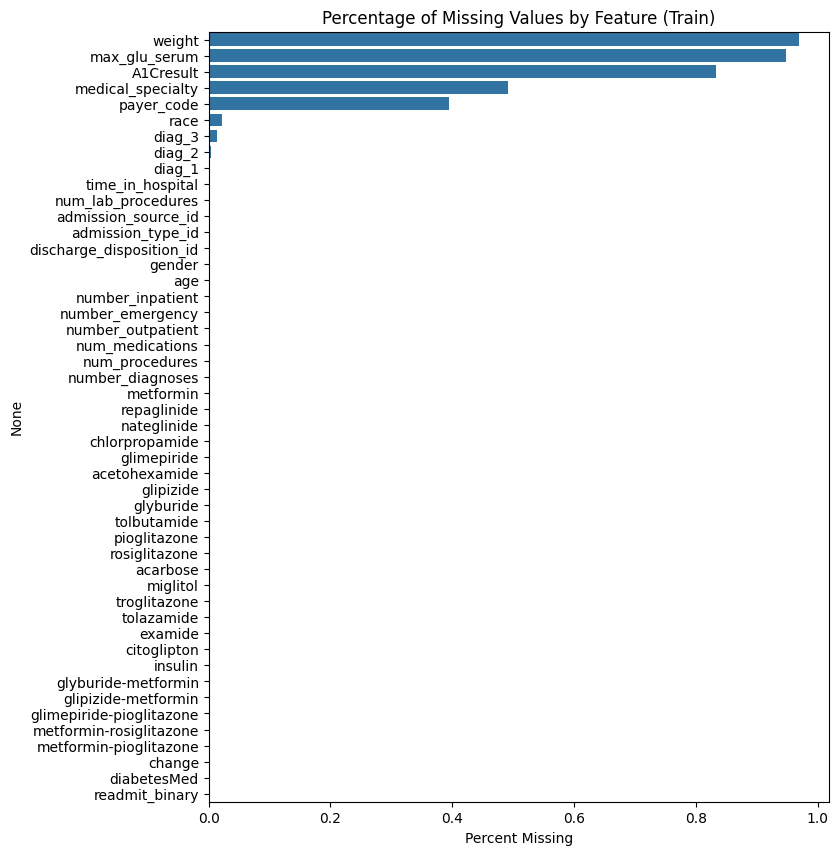

In [ ]:
# Missingness in train
missing = train_df.isnull().mean().sort_values(ascending=False)
plt.figure(figsize=(8,10))
sns.barplot(x=missing, y=missing.index)
plt.title("Percentage of Missing Values by Feature (Train)")
plt.xlabel("Percent Missing")
plt.show()

We are checking the imbalance between our target class to check how many people are coming for a re-admission.

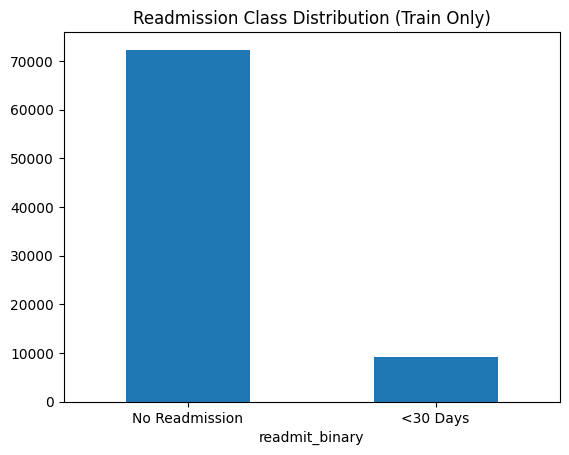

In [ ]:
# Class balance
train_df['readmit_binary'].value_counts().plot(kind='bar')
plt.title("Readmission Class Distribution (Train Only)")
plt.xticks([0,1], ['No Readmission', '<30 Days'], rotation=0)
plt.show()

From the graph above we can clearly get to a conclusion that most of the patients were not re-admitted whereas only a small portion(around 10000) people were re-admitted within 30 days. With this, we can come to a conclusion that the target class i.e re-admission is highly imbalanced.

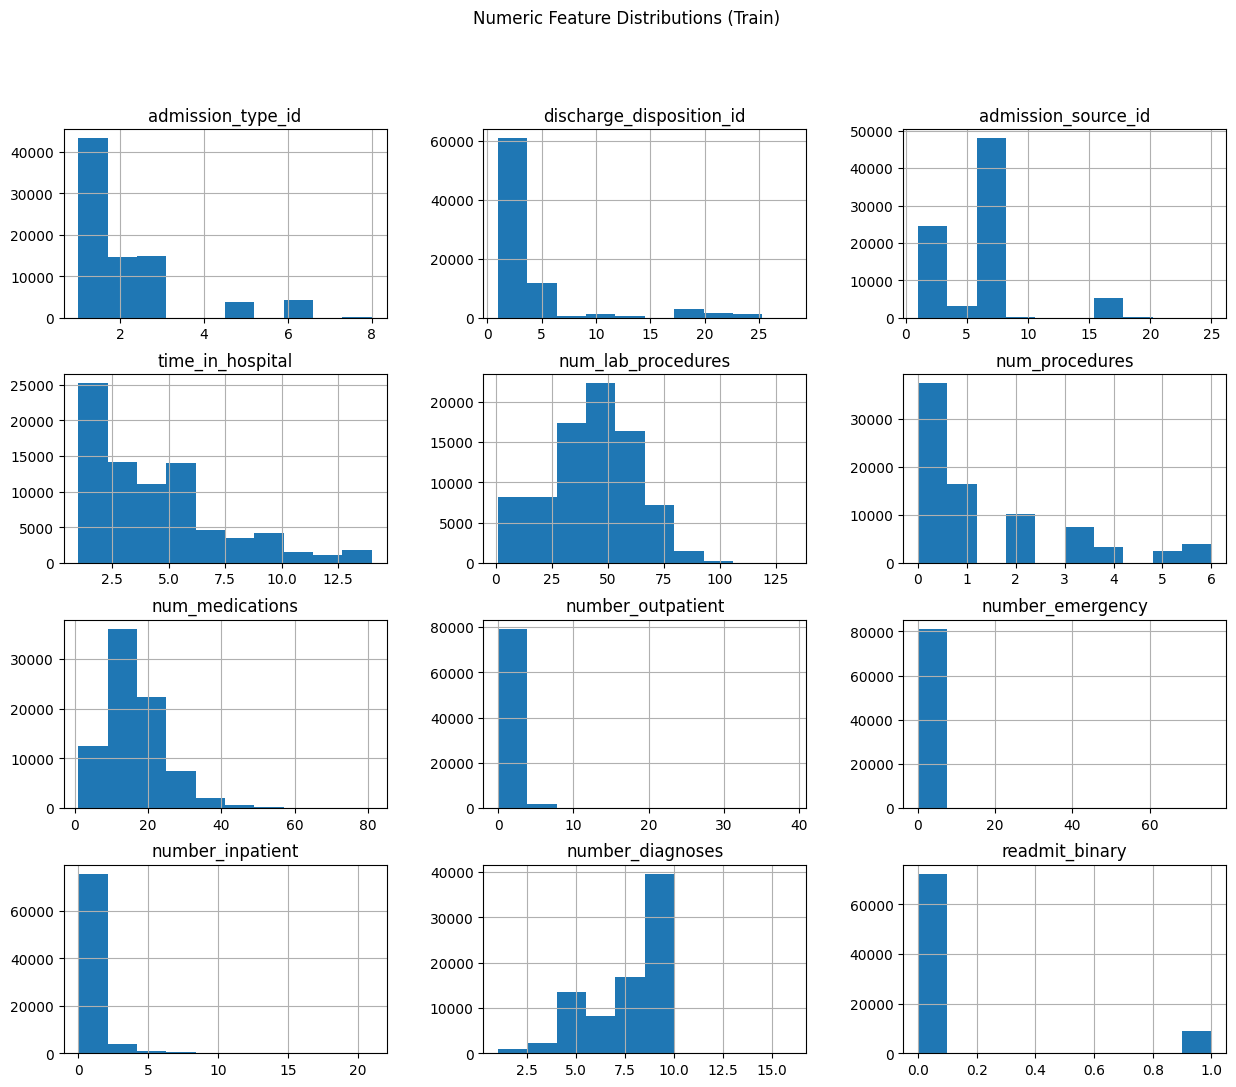

In [ ]:
# Numeric distributions
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
train_df[numeric_cols].hist(figsize=(15,12))
plt.suptitle("Numeric Feature Distributions (Train)")
plt.show()

These histograms show how each numeric feature in the training data is distributed. Most features are highly skewed, meaning a large number of patients fall into a small range of values. For example, hospital stay, number of procedures, and number of medications are all concentrated at low values. Lab procedures show a more spread-out distribution. Features like outpatient, emergency, and inpatient visits have many zeros, indicating most patients did not have prior visits. The final plot again confirms the class imbalance in the target variable.

The code below deals with the IDS_Mapping dataset. It converts the original numeric hospital admission, discharge, and source IDs into meaningful category names.

In [ ]:
# Admission type mapping (using IDs mapping file description)
admission_map = {
    1: 'Emergency',
    2: 'Urgent',
    3: 'Elective',
    4: 'Newborn',
    5: 'NotAvailable',
    6: 'Null',
    7: 'Trauma',
    8: 'NotMapped'
}

def map_discharge(x):
    if x in [1, 6]:
        return 'Home'
    if x in [2,3,4,5,8,22,23,24,27,30]:
        return 'Transfer'
    if x in [13,14,19,20,21]:
        return 'Hospice'
    if x == 11:
        return 'Death'
    return 'Other'

def map_source(x):
    if x in [1,2,3]:
        return 'Referral'
    if x == 7:
        return 'Emergency'
    if x in [4,5,6,10,18,19,22,25,26]:
        return 'Transfer'
    if x in [11,12,13,14,23,24]:
        return 'Birth'
    return 'Other'

for df_tmp in [train_df, test_df]:
    df_tmp['admission_type_simplified'] = df_tmp['admission_type_id'].map(admission_map).fillna('Other')
    df_tmp.drop(columns=['admission_type_id'], inplace=True)

    df_tmp['discharge_category'] = df_tmp['discharge_disposition_id'].apply(map_discharge)
    df_tmp.drop(columns=['discharge_disposition_id'], inplace=True)

    df_tmp['admission_source_simplified'] = df_tmp['admission_source_id'].apply(map_source)
    df_tmp.drop(columns=['admission_source_id'], inplace=True)

admission_map changes admission type IDs (1–8) into labels like Emergency, Urgent, Elective, etc.

map_discharge() groups discharge IDs into broader categories such as Home, Transfer, Hospice, Death, or Other.

map_source() groups admission source IDs into Referral, Emergency, Transfer, Birth, or Other.

The code below takes into account the attributes which are very rare in the dataset i.e less than 1% of the training dataset. We are doing this to ensure that the model does not overfit and helps in making the model more stable

In [ ]:
def compute_rare_mapping(train_series, threshold=0.01):
    # threshold = 1% of training data
    value_counts = train_series.value_counts(normalize=True)
    rare = value_counts[value_counts < threshold].index
    mapping = {cat: ('Other' if cat in rare else cat) for cat in value_counts.index}
    return mapping

for col in ['race', 'gender',
            'admission_type_simplified',
            'admission_source_simplified',
            'discharge_category']:
    mapping = compute_rare_mapping(train_df[col])
    train_df[col] = train_df[col].map(mapping).fillna('Other')
    test_df[col]  = test_df[col].map(mapping).fillna('Other')

The variable named value_counts gives us the frequency of each category.
the variable named 'rare' identifies these rare categoris.
The 'mapping function helps build a dictionary that replaces categories with the word 'Other'

In the code below, we are trying to identify the column types(categorical or numerical) and are separating out with variables named 'cat_cols' and 'num_cols' which represent categorical and numerical columns respectively.

Additionally, we are removing the target attribute 're-admit' for now since the model should not consider it as a feature.

We are also filling out the missing values using the median value for the columns which are numerical and for the columns which are categorical, we will replace the values with the word 'Missing'

In [ ]:
# Identify categorical & numeric columns on TRAIN
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()

# Remove target from these lists
if 'readmit_binary' in cat_cols:
    cat_cols.remove('readmit_binary')
if 'readmit_binary' in num_cols:
    num_cols.remove('readmit_binary')

# Categorical: replace NaN with 'Missing'
for df_tmp in [train_df, test_df]:
    df_tmp[cat_cols] = df_tmp[cat_cols].fillna('Missing')

# Numeric: fit medians on TRAIN, apply to both
num_medians = train_df[num_cols].median()
train_df[num_cols] = train_df[num_cols].fillna(num_medians)
test_df[num_cols]  = test_df[num_cols].fillna(num_medians)

The code below deals with the mapping of the 'age' column. The age has been provided to us as range for example '20-30'. The model will not be able to read the age column properly hence we are converting it and keeping the age column as the median value of it's range. Hence the bracket of '20-30' becomes '25' and similarly other brackets as well.

In [ ]:
age_mapping = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}

for df_tmp in [train_df, test_df]:
    df_tmp['age'] = df_tmp['age'].astype(str).str.strip()
    df_tmp['age'] = df_tmp['age'].map(lambda x: age_mapping.get(x, np.nan))

Feature Engineering

The code below creates 5 different features that will help us understand how the model will work.

1. Diabetes medication column list:
Provides with the list of all diabetes related medication columns so that we can count how many diabetes meds a patient is currently using.

2. Diagnosis Mapping Function:
This function converts the diagnosis codes into groups such as : Circulatory, Diabetes, Respiratory, Digestive and Others/Unknown.

3. Feature Engineering for each dataset:
We are considering a number of different feature of the dataset here:

*   Total List: A single feature that captures how often the patient has visited the hospital
*   Prior Admission Flag: Determines whether the patient had a prior inpatient admissions determined by the binary value "1" or "0"

*   A1C test flag: Shows whether the patient had an A1C test which is one of the important tests for diabetes control
*   Insulin Usage Flag: Determines whether the patient is taking insulin or not determined by the binary value "1" or "0".
*   Number of diabetes medications: Counts how many diabetes drugs the patient has been prescribed.
*   Diagnosis Grouping:
Converts the three diagnosis code columns into high-level categories.
Then removes the original raw code columns.

4. Keeping only top 10 medical specialities
As the heading suggests, we are keeping only the top 10 medical specialities so that it helps in preventing too many one-hot categories and eventually reduces the noise of data.








In [ ]:
diabetes_med_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
    'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
    'insulin','glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone'
]

def map_diag(code):
    try:
        code = float(code)
    except:
        return 'Unknown'
    if 390 <= code <= 459 or code == 785:
        return 'Circulatory'
    elif 250 <= code < 251:
        return 'Diabetes'
    elif 460 <= code <= 519 or code == 786:
        return 'Respiratory'
    elif 520 <= code <= 579 or code == 787:
        return 'Digestive'
    else:
        return 'Other'

for df_tmp in [train_df, test_df]:
    # Total visits
    df_tmp['total_visits'] = (
        df_tmp['number_outpatient'] +
        df_tmp['number_inpatient'] +
        df_tmp['number_emergency']
    )

    # Prior admission flag
    df_tmp['prior_admission_flag'] = (df_tmp['number_inpatient'] > 0).astype(int)

    # A1C presence flag
    df_tmp['has_A1C'] = df_tmp['A1Cresult'].apply(
        lambda x: 0 if (pd.isna(x) or x == 'None') else 1
    )

    # Insulin flag
    df_tmp['insulin_flag'] = df_tmp['insulin'].apply(
        lambda x: 1 if x != 'No' else 0
    )

    # Count diabetes meds
    df_tmp['num_diabetes_meds'] = df_tmp[diabetes_med_cols].apply(
        lambda row: (row != 'No').sum(), axis=1
    )

    # Diagnosis grouping
    df_tmp['diag_1_group'] = df_tmp['diag_1'].apply(map_diag)
    df_tmp['diag_2_group'] = df_tmp['diag_2'].apply(map_diag)
    df_tmp['diag_3_group'] = df_tmp['diag_3'].apply(map_diag)
    df_tmp.drop(columns=['diag_1', 'diag_2', 'diag_3'], inplace=True)

# Top 10 medical specialties (fit on train)
top_specialties = train_df['medical_specialty'].value_counts().nlargest(10).index

for df_tmp in [train_df, test_df]:
    df_tmp['medical_specialty'] = df_tmp['medical_specialty'].apply(
        lambda x: x if x in top_specialties else 'Other'
    )

The code below detects the categorical columns first and then proceeds to start one-hot encoding for these columns.
This converts every categorical column into 0/1 dummy variables.

Example:
gender = gender_Male,
race = race_AfricanAmerican, etc.

drop_first=True avoids the dummy variable trap (perfect multicollinearity).

The code also aligns the training and testing dataset's columns together so that they both have the exact same columns.

In [ ]:
# Identify categorical columns after all feature engineering
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
if 'readmit_binary' in cat_cols:
    cat_cols.remove('readmit_binary')  # just in case

# One-hot encode train and test
train_encoded = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
test_encoded  = pd.get_dummies(test_df,  columns=cat_cols, drop_first=True)

# Align test columns to train columns
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

print("Encoded train shape:", train_encoded.shape)
print("Encoded test shape:", test_encoded.shape)

Encoded train shape: (81412, 136)
Encoded test shape: (20354, 136)


The penultimate code before the model training. We are splitting the features and target for the training and the testing part.

We are also selecting some columns like hospital stay and lab procedures for scaling and standardizing it since they are continuous numerical features. This will help in model training and eventually enhances the performance of the models.

In [ ]:
X_train = train_encoded.drop(columns=['readmit_binary'])
y_train = train_encoded['readmit_binary']

X_test = test_encoded.drop(columns=['readmit_binary'])
y_test = test_encoded['readmit_binary']

# Choose numeric columns to scale (continuous)
numeric_to_scale = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age',
    'total_visits', 'num_diabetes_meds'
]
numeric_to_scale = [col for col in numeric_to_scale if col in X_train.columns]

scaler = StandardScaler()
X_train[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test[numeric_to_scale]  = scaler.transform(X_test[numeric_to_scale])

Model Training

Logistic Regression:
Logistic regression models how patient features affect the odds of being readmitted within 30 days. It assigns coefficients that show which factors increase risk, for example:

More total visits will result in higher chance of readmission.
Longer hospital stays → more complex cases → higher risk.
Previous inpatient admissions will result in higher risk.
Diagnosis groups and discharge types → highlight medical conditions or discharge plans linked to readmission.

Advantages:
Very interpretable — you can clearly explain how each feature affects readmission risk.
A strong baseline model to compare others against.

Disadvantages:
Readmission risk is often non-linear and depends on interactions (e.g., high visits and long hospital stay).
Logistic regression cannot naturally capture these complex patterns without manual feature engineering.

KNN:
KNN finds the 4 most similar patients in the training data (based on features like hospital stay, medications, total visits, age, diagnosis groups, discharge type, etc.) and predicts readmission by looking at how many of those similar patients were readmitted.

Advantages:
Required since your professor asked for k=4.
Easy to explain in healthcare terms: “We predict a patient’s risk by looking at similar past patients.”

Disadvantages:
After one-hot encoding many categories, the dataset becomes high-dimensional, making distance-based comparisons less meaningful.

It is very sensitive to feature scaling.

Random Forest
Random Forest builds many decision trees that split on meaningful clinical thresholds, such as:

total_visits > 3

time_in_hospital > 7

discharge_category = Transfer

diag_1_group = Circulatory

age > 70

num_diabetes_meds > 4

insulin_flag = 1

Each tree learns patterns like:
“If total_visits > 3 AND time_in_hospital > 5 AND discharge_category is Transfer is related higher readmission risk.”

The model:

Captures non-linear patterns

Automatically learns interactions between features

Handles complex relationships that logistic regression cannot capture easily

Advantages:
The dataset is tabular with mixed feature types (numeric + encoded categorical).
Many features naturally involve thresholds (visits, medications, hospital stay), which trees learn very well.
Random Forest provides feature importance, often highlighting:

total_visits

time_in_hospital

prior_admission_flag

diag_1_group


GRADIENT BOOSTING:
Gradient Boosting builds trees one after another, with each new tree trying to fix the mistakes made by previous trees.
So if the early model struggles to identify high-risk patients (e.g., diabetics with many prior visits), later trees focus specifically on correcting those errors. This helps it capture subtle patterns, especially in the minority class (<30-day readmission).

Advantages:
The readmission problem is noisy and imbalanced.
Gradient Boosting often achieves higher ROC-AUC and better recall for the <30 class than Random Forest.
It adapts well to complex relationships in tabular clinical data.

Disadvantages:
More sensitive to tuning (learning rate, depth, etc.).
Slower than Random Forest, but still efficient for your dataset size.

SUPPORT VECTOR MACHINE

Used support vector machine since the dataset had high dimensionality i.e lots of features after one-hot encoding.

Additionally, the dataset has lots of non-linear relationships and class imbalance hence SVM is an ideal model to be trained.

It can learn complex relationships between factors like age, diagnosis, prior visits, and discharge type—patterns logistic regression can’t capture without extra engineering. Using class_weight='balanced' also helps SVM pay more attention to the minority class (<30-day readmissions), improving recall.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {}

# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_params = {'C': [0.01, 0.1, 1, 10]}

log_grid = GridSearchCV(log_reg, log_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
log_grid.fit(X_train, y_train)
models['Logistic Regression'] = log_grid.best_estimator_
print("Logistic best AUC (CV):", log_grid.best_score_)

# 2. KNN (including k=4 as your prof asked)
knn = KNeighborsClassifier()
knn_params = {'n_neighbors': [3, 4, 5, 7], 'weights': ['uniform', 'distance']}

knn_grid = GridSearchCV(knn, knn_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
knn_grid.fit(X_train, y_train)
models['KNN'] = knn_grid.best_estimator_
print("KNN best AUC (CV):", knn_grid.best_score_)

# 3. Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(rf, rf_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)
models['Random Forest'] = rf_grid.best_estimator_
print("RF best AUC (CV):", rf_grid.best_score_)

# 4. Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
gb_grid = GridSearchCV(gb, gb_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)
models['Gradient Boosting'] = gb_grid.best_estimator_
print("GB best AUC (CV):", gb_grid.best_score_)

# 5. Linear SVM with probability calibration
svm_linear = LinearSVC(class_weight='balanced')
svm_params = {'C': [0.01, 0.1, 1, 10]}

svm_grid = GridSearchCV(svm_linear, svm_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
svm_grid.fit(X_train, y_train)
svm_best = CalibratedClassifierCV(svm_grid.best_estimator_, cv=cv)
svm_best.fit(X_train, y_train)
models['Linear SVM'] = svm_best

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Logistic best AUC (CV): 0.6589373785574875
Fitting 5 folds for each of 8 candidates, totalling 40 fits
KNN best AUC (CV): 0.5758794451559497
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RF best AUC (CV): 0.6603332011019907
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GB best AUC (CV): 0.6642994550924388
Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [ ]:
results = []

for name, model in models.items():
    print("Evaluating:", name)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print("-"*40)

results_df = pd.DataFrame(results)
results_df

Evaluating: Logistic Regression
Accuracy: 0.6437
Precision: 0.1765
Recall: 0.5984
F1 Score: 0.2726
ROC-AUC: 0.6658
PR-AUC: 0.2062
----------------------------------------
Evaluating: KNN
Accuracy: 0.8852
Precision: 0.3640
Recall: 0.0383
F1 Score: 0.0693
ROC-AUC: 0.5787
PR-AUC: 0.1622
----------------------------------------
Evaluating: Random Forest
Accuracy: 0.6742
Precision: 0.1854
Recall: 0.5658
F1 Score: 0.2793
ROC-AUC: 0.6701
PR-AUC: 0.2114
----------------------------------------
Evaluating: Gradient Boosting
Accuracy: 0.8886
Precision: 0.5254
Recall: 0.0137
F1 Score: 0.0266
ROC-AUC: 0.6735
PR-AUC: 0.2097
----------------------------------------
Evaluating: Linear SVM
Accuracy: 0.8885
Precision: 0.5385
Recall: 0.0062
F1 Score: 0.0122
ROC-AUC: 0.6651
PR-AUC: 0.2039
----------------------------------------


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.643657,0.176494,0.598415,0.272591,0.665768,0.206249
1,KNN,0.885231,0.364017,0.038309,0.069323,0.578717,0.162206
2,Random Forest,0.674167,0.185399,0.565830,0.279287,0.670140,0.211409
3,Gradient Boosting,0.888572,0.525424,0.013650,0.026609,0.673496,0.209667
4,Linear SVM,0.888523,0.538462,0.006165,0.012190,0.665064,0.203875


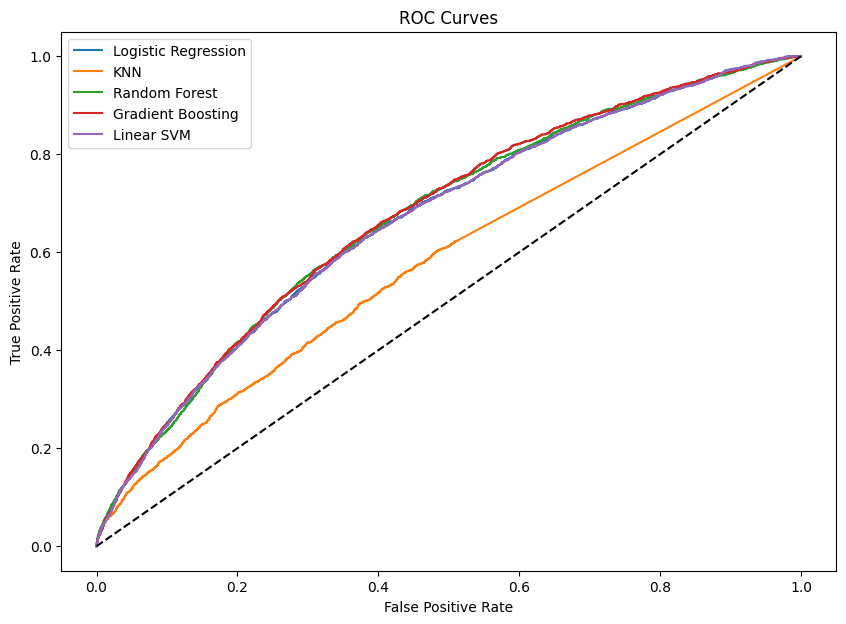

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name}")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

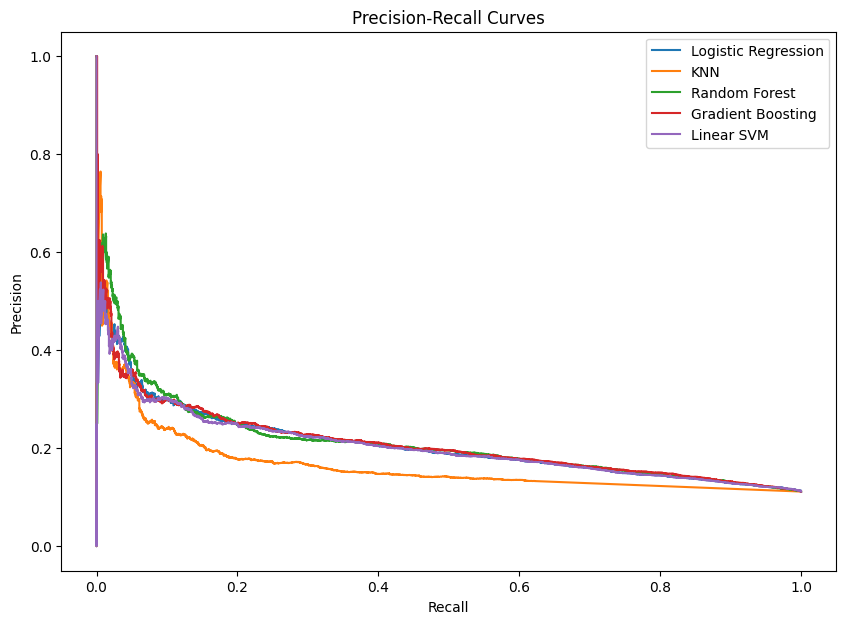

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 7))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name}")

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

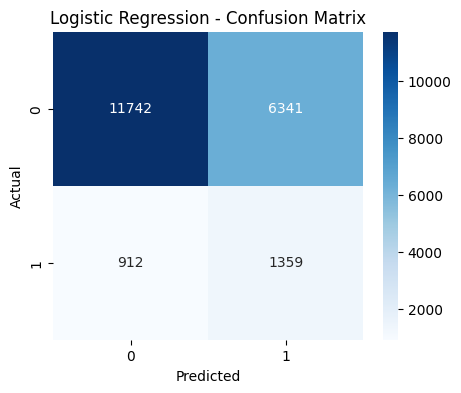

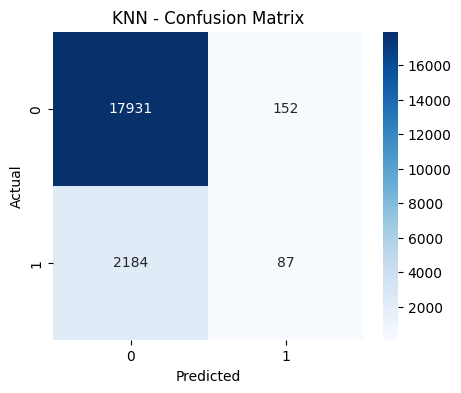

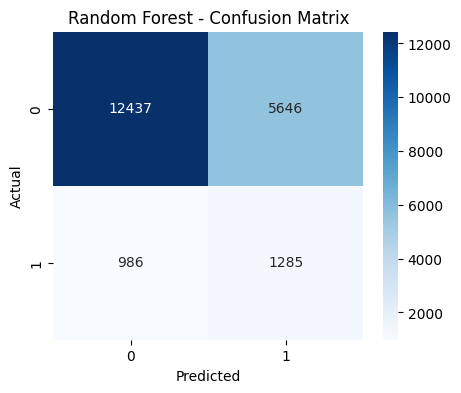

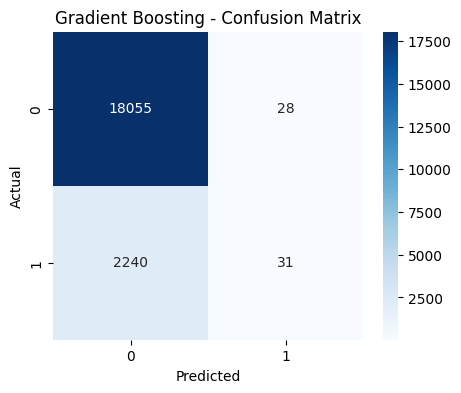

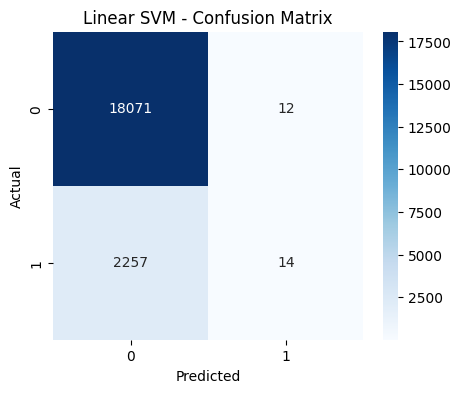

In [ ]:
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

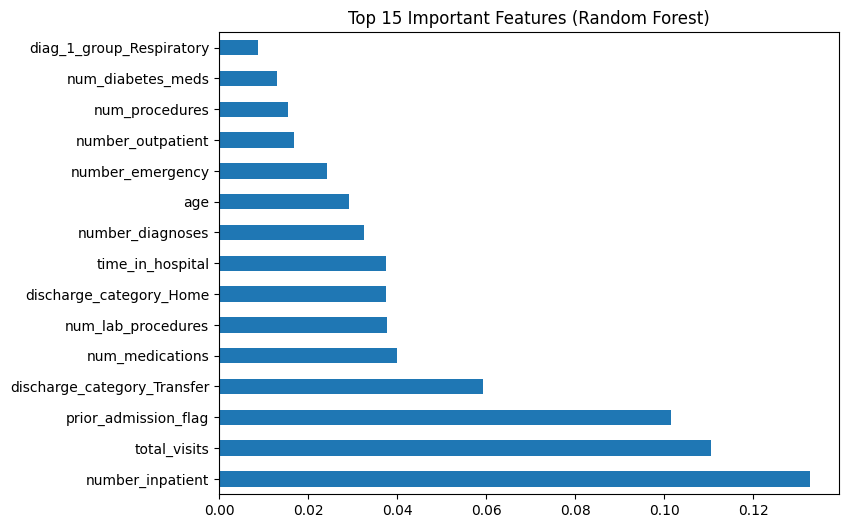

In [ ]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.nlargest(15).plot(kind='barh', figsize=(8,6))
plt.title("Top 15 Important Features (Random Forest)")
plt.show()

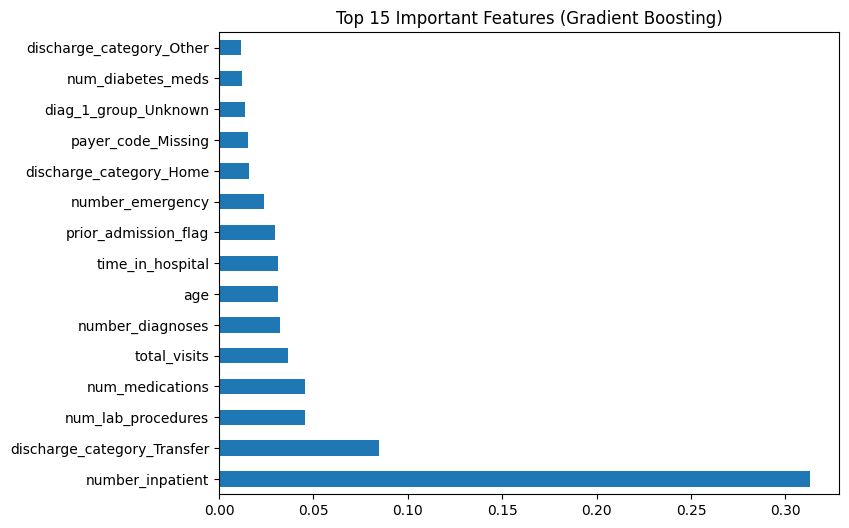

In [ ]:
gb = models["Gradient Boosting"]
importances = pd.Series(gb.feature_importances_, index=X_train.columns)
importances.nlargest(15).plot(kind='barh', figsize=(8,6))
plt.title("Top 15 Important Features (Gradient Boosting)")
plt.show()

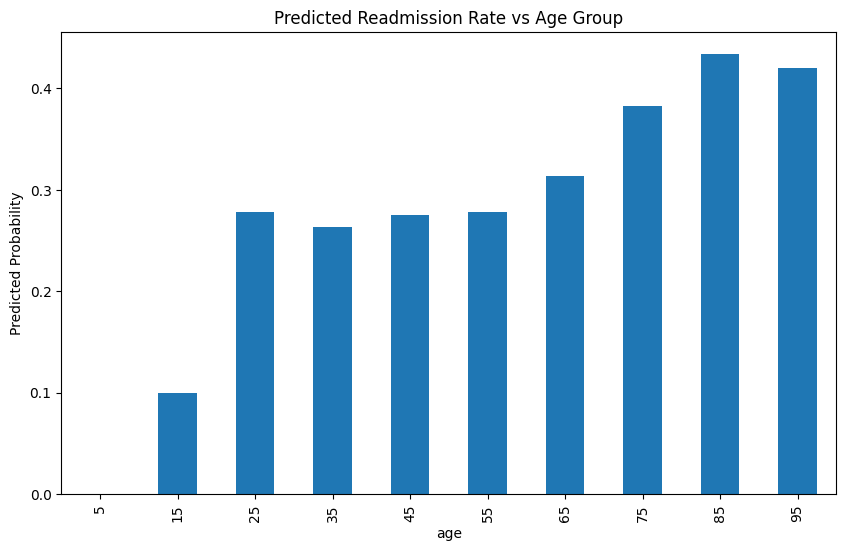

In [ ]:
test_df_copy = test_df.copy()
test_df_copy['prediction'] = models["Random Forest"].predict(X_test)

test_df_copy.groupby('age')['prediction'].mean().plot(kind='bar', figsize=(10,6))
plt.title("Predicted Readmission Rate vs Age Group")
plt.ylabel("Predicted Probability")
plt.show()